# Vizualizace délky pobytu na pohotovosti pomocí PROC BOX

## Shrnutí pro vedení

Analýza provozu nemocnice, která pomocí PROC BOXPLOT (s aliasem PROC BOX) porovnává délku pobytu na pohotovosti napříč třemi klinickými službami. Krabicové grafy vedle sebe na první pohled ukazují medián, kvartily, průměr a odlehlé hodnoty dlouhých pobytů pro každou službu.

Napříč 100 simulovanými případy medián délky pobytu plynule roste ze **40,0 hodin u služby Medicine** na **50,4 hodin u služby Surgery** až na **60,5 hodin u služby Trauma** a průměry sledují stejné pořadí (41,6, 54,6, 62,8 hodin). Služba Surgery má tři vysoké odlehlé hodnoty nad horním vousem (až 84,3 hodin) — případy čekající na lůžko, které spotřebují nejvíce lůžkohodin. Notebook zobrazuje porovnání třemi způsoby: schematickým grafem, překrytím trendu průměru a horizontálním uspořádáním.

## Zdroje dat

Všechna data jsou generována vloženě prvním krokem DATA (`call streaminit(20260531)`); nepoužívá se žádný externí ani síťový vstup.

**`ed_los`** — jeden řádek na každý případ na pohotovosti (100 řádků)

| Proměnná | Typ | Popis |
|----------|------|-------------|
| `PatientID` | Num | Pořadový identifikátor případu (1-100) |
| `Department` | Char(12) | Přijímající služba: Medicine, Surgery, Trauma |
| `Severity` | Char(8) | Naléhavost triáže: Routine (~55 %), Urgent (~30 %), Critical (~15 %) |
| `LOS_Hours` | Num | Délka pobytu v hodinách; průměr daný službou a naléhavostí plus normální šum, s občasným šokem dlouhého pobytu (se štítkem "Length of Stay (hours)") |

Realizovaná skladba je Medicine 34 / Surgery 36 / Trauma 30 případů a podle naléhavosti triáže Routine 51 / Urgent 35 / Critical 14.

# Vizualizace délky pobytu na pohotovosti pomocí PROC BOX

Délka pobytu (LOS) je jednou z nejsledovanějších provozních metrik na nemocniční pohotovosti: řídí dostupnost lůžek, personální obsazení, propustnost pacientů a skóre kvality. Samotné průměry příběh skrývají — pro provozní tým je důležité *rozpětí* pobytů, *odlehlé hodnoty*, které vážou zdroje, a jak se rozdělení liší napříč klinickými službami.

PROC BOX (alias pro PROC BOXPLOT) je pro přesně takové porovnání vytvořen. Kreslí krabicové grafy s vousy vedle sebe a označuje medián, kvartily, průměr a extrémní pozorování každé skupiny, takže analytik může tvar rozdělení LOS každé služby přečíst na první pohled.

V tomto notebooku:

1. Vygenerujeme syntetickou datovou sadu případů na pohotovosti, která zapadá do prostředí se 100 pozorováními.
2. Vytvoříme schematický krabicový graf LOS podle oddělení spolu s doprovodnou tabulkou statistik.
3. Překryjeme čáru trendu průměru pomocí `BOXCONNECT=MEAN`, aby byl gradient mezi službami explicitní.
4. Znovu vykreslíme stejné porovnání horizontálně pomocí `HORIZONTAL`.

## Krok 1 — Vygenerování syntetických dat o případech na pohotovosti

Simulujeme 100 případů na pohotovosti. Každý pacient je přiřazen k jedné ze tří klinických služeb (Medicine, Surgery, Trauma) a k naléhavosti triáže (Routine, Urgent, Critical). Délka pobytu je sestavena ze základní hodnoty specifické pro službu, posunuté nahoru u pacientů s vyšší naléhavostí, s normálně rozděleným šumem. Malá část případů dostane navíc šok dlouhého pobytu, aby napodobil těžký pravý chvost, který reálná data z pohotovosti vždy vykazují (čekání na lůžko, přijetí čekající na lůžko lůžkového oddělení). Pevné semínko v `call streaminit` činí datovou sadu plně reprodukovatelnou.

In [1]:
VOLBY linesize=96;

data ed_los;
   CALL streaminit(20260531);
   DÉLKA Department $ 20 Severity $ 16;
   OPAKUJ PatientID = 1 TO 100;
      d = rand('integer', 1, 3);
      KDYŽ d = 1 PAK Department = "Interní";
      JINAK KDYŽ d = 2 PAK Department = "Chirurgie";
      JINAK Department = "Úrazové";

      u = rand('uniform');
      KDYŽ u < 0.55 PAK s = 1;
      JINAK KDYŽ u < 0.85 PAK s = 2;
      JINAK s = 3;
      KDYŽ s = 1 PAK Severity = "Běžná";
      JINAK KDYŽ s = 2 PAK Severity = "Naléhavá";
      JINAK Severity = "Kritická";

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      KDYŽ rand('uniform') < 0.06 PAK
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      KDYŽ LOS_Hours < 2 PAK LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      VÝSTUP;
   KONEC;
   ODSTRANIT d u s BASE;
   ŠTÍTEK LOS_Hours  = "Délka pobytu (hodiny)"
          Department = "Oddělení"
          Severity   = "Závažnost";
SPUSTIT;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Krok 2 — Seřazení podle skupinové proměnné

PROC BOX očekává, že skupinová proměnná (vodorovná osa) je seřazena tak, aby pozorování každé skupiny byla souvislá. Před vykreslením seřadíme podle `Department`.

In [2]:
PROCEDURA ŘADIT data=ed_los;
   PODLE Department;
SPUSTIT;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Krok 3 — Schematický krabicový graf

Jádro analýzy. Syntaxe `PLOT analysis-var * group-var` požaduje jednu krabici na oddělení. `BOXSTYLE=SCHEMATIC` produkuje klasický Tukeyho schematický graf: vousy sahají k nejextrémnějším pozorováním v rámci 1,5násobku mezikvartilového rozpětí a jakékoli body za tímto rozsahem se kreslí jednotlivě jako odlehlé hodnoty — ideální pro odhalení případů dlouhého pobytu, které zatěžují kapacitu.

`NOHLABEL` potlačuje nadbytečný popisek vodorovné osy, protože názvy oddělení jsou samovysvětlující. Vedle grafu PROC BOXPLOT vytiskne tabulku statistik uvádějící pro každé oddělení N, minimum, kvartily, medián, maximum, průměr a směrodatnou odchylku.

                           Délka pobytu na pohotovosti podle oddělení                           

                         Délka pobytu na pohotovosti podle oddělení

                                     The BOXPLOT Procedure

Schematic Plots for Délka pobytu (hodiny)

Oddělení              N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Interní              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Úrazové              30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Délka pobytu na pohotovosti podle oddělení.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


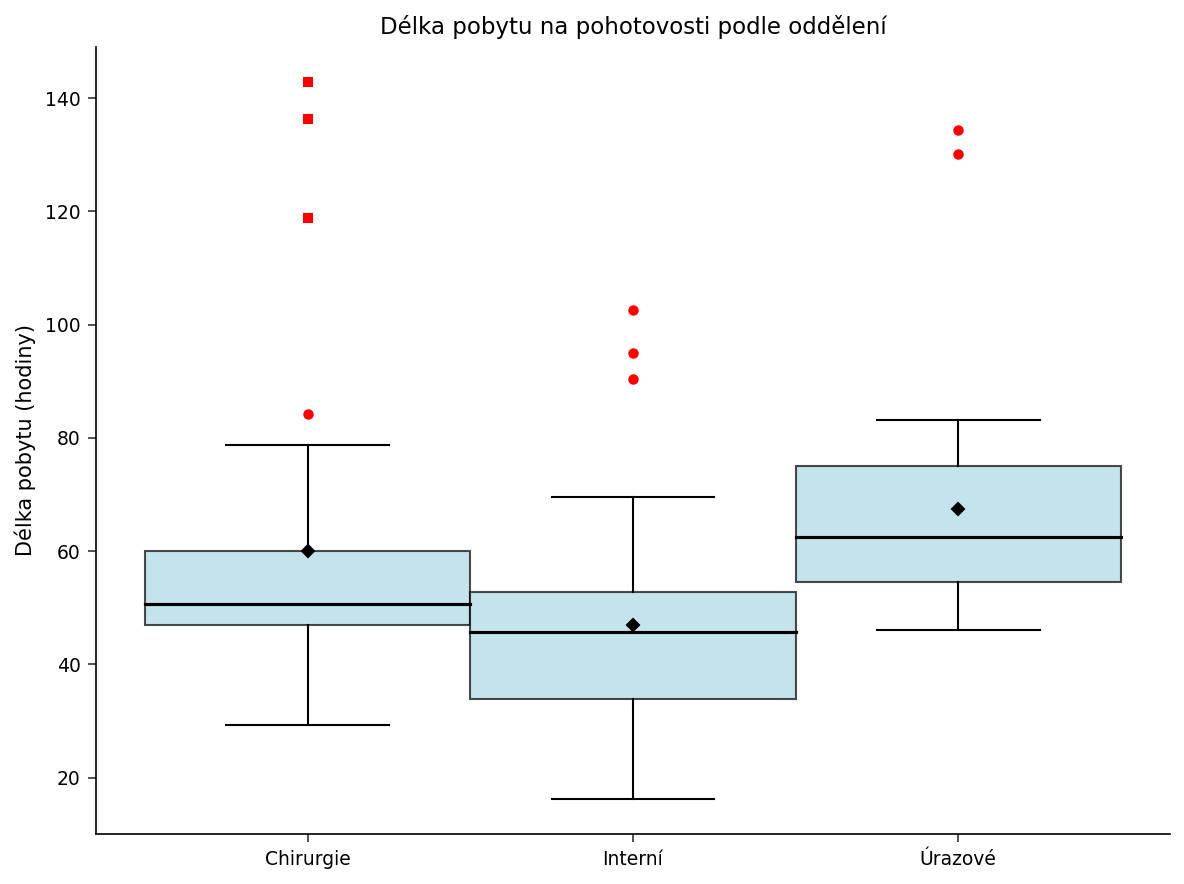

In [3]:
NÁZEV "Délka pobytu na pohotovosti podle oddělení";
PROCEDURA boxplot data=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
SPUSTIT;

## Krok 4 — Překrytí čáry trendu průměru

Abychom učinili gradient mezi službami explicitní, přidáme `BOXCONNECT=MEAN`. PROC BOXPLOT pak nakreslí spojnici procházející průměrem každé krabice (kosočtvercové značky), čímž ze tří samostatných rozdělení vytvoří jeden čitelný trend. Protože oddělení jsou seřazena Medicine → Surgery → Trauma, rostoucí spojnice shrnuje eskalaci průměrné délky pobytu jedním tahem — užitečné vodítko pro provozní dashboard.

                   Délka pobytu na pohotovosti podle oddělení - trend průměru                   

                Délka pobytu na pohotovosti podle oddělení - trend průměru

                                     The BOXPLOT Procedure

Schematic Plots for Délka pobytu (hodiny)

Oddělení              N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Interní              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Úrazové              30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Délka pobytu na pohotovosti podle oddělení - trend průměru.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


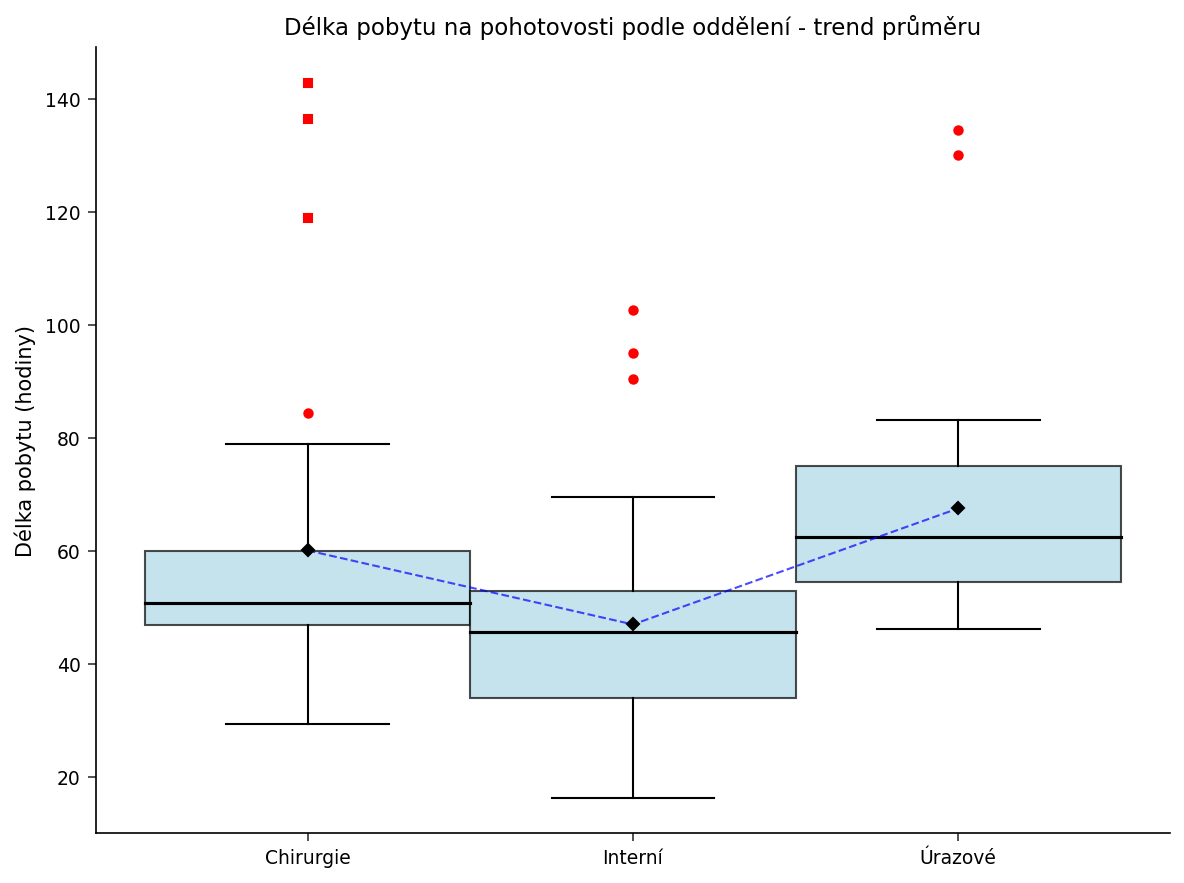

In [4]:
NÁZEV "Délka pobytu na pohotovosti podle oddělení - trend průměru";
PROCEDURA boxplot data=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
SPUSTIT;

## Krok 5 — Horizontální uspořádání

Stejné porovnání se přirozeně čte i naležato. Přidání `HORIZONTAL` prohodí osy, takže krabice běží zleva doprava s odezvou na ose x — uspořádání, které se lépe škáluje, když jsou názvy služeb dlouhé nebo početné, a které mnoho provozních dashboardů preferuje. Statistiky jsou totožné se svislým pohledem; mění se pouze orientace.

                   Délka pobytu na pohotovosti podle oddělení - horizontálně                    

                 Délka pobytu na pohotovosti podle oddělení - horizontálně

                                     The BOXPLOT Procedure

Schematic Plots for Délka pobytu (hodiny)

Oddělení              N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Interní              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Úrazové              30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Délka pobytu na pohotovosti podle oddělení - horizontálně.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


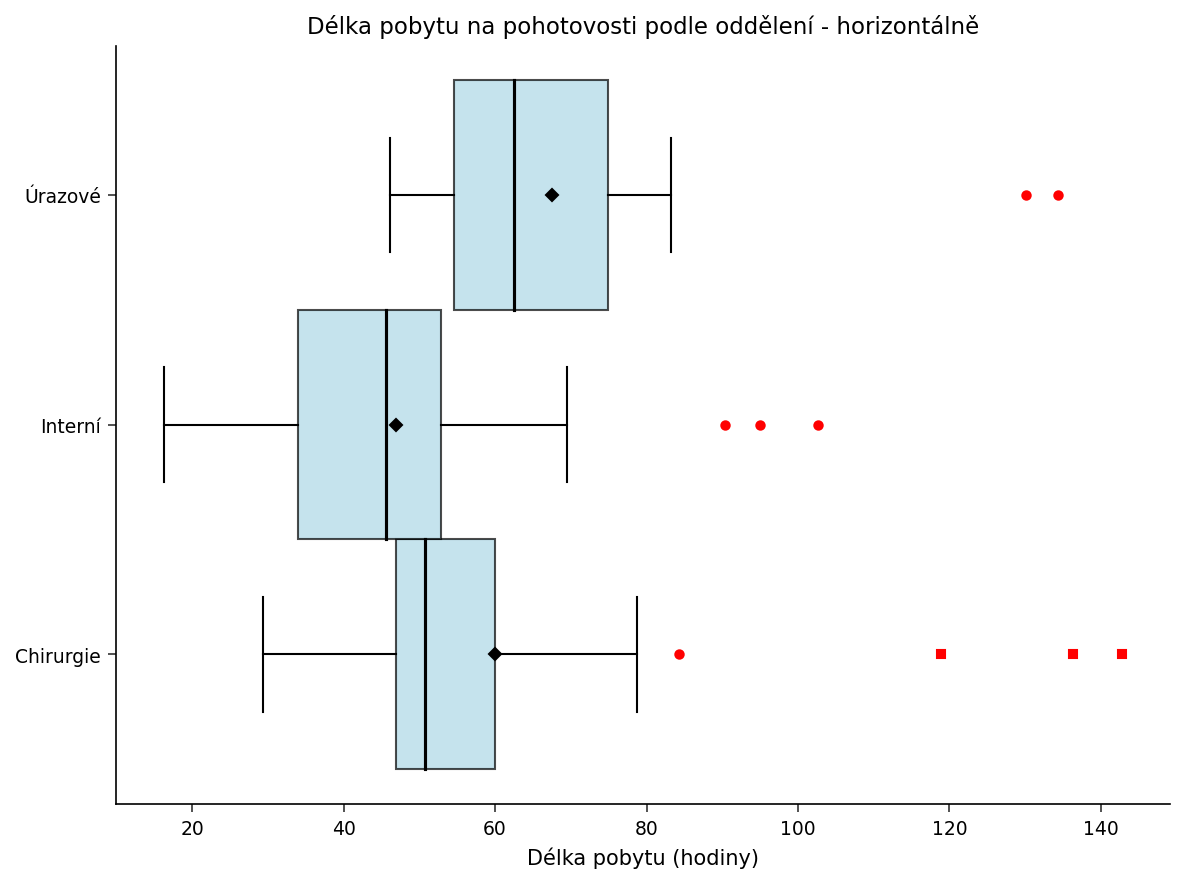

In [5]:
NÁZEV "Délka pobytu na pohotovosti podle oddělení - horizontálně";
PROCEDURA boxplot data=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
SPUSTIT;

## Interpretace výsledků

Krabicové grafy a doprovodná tabulka statistik převádějí surová data LOS do provozně využitelného obrazu:

- **Jasný gradient mezi službami.** Medián délky pobytu roste monotónně napříč třemi službami: **Medicine 40,0 h → Surgery 50,4 h → Trauma 60,5 h**. Průměry vypravují stejný příběh (41,6, 54,6, 62,8 h) a čára `BOXCONNECT=MEAN` v Kroku 4 kreslí tuto eskalaci jako jediný rostoucí trend. Pacienti služby Trauma zůstávají v průměru zhruba o 50 % déle než pacienti služby Medicine.

- **Variabilita je stejně důležitá jako medián.** Mezikvartilové rozpětí (výška krabice) je nejširší u služby Medicine (Q1 32,8 h až Q3 51,2 h, rozpětí 18,3 hodiny) a nejužší u služby Trauma (Q1 54,5 h až Q3 68,5 h, rozpětí 14,0 hodiny). Medicine tedy není jen nejkratší službou, ale také nejméně předvídatelnou — vlastnost, která komplikuje prognózy správy lůžek.

- **Odlehlé hodnoty označují případy čekání na lůžko.** Schematické vousy se zastavují na 1,5 × IQR, takže tři červené body nad horním vousem služby Surgery (s vrcholem na 84,3 h) vyčnívají jako skutečné případy dlouhého pobytu — přesně ty případy čekání na lůžko, které spotřebují nepoměrné množství lůžkohodin. Medicine a Trauma v tomto vzorku nevykazují žádné body za svými vousy.

- **Rozsah vypráví příběh plánování kapacity.** Pozorované pobyty se pohybují od 16,3 do 69,5 h u služby Medicine, od 29,3 do 84,3 h u služby Surgery a od 46,1 do 83,2 h u služby Trauma. Trauma nikdy neprodukuje krátký pobyt (její minimum 46,1 h překračuje medián služby Medicine), což je to, co by provozní tým očekával od nejnáročnější služby.

Společně tyto pohledy poskytují vedení pohotovosti obhájitelný základ zohledňující rozdělení pro personální obsazení a plánování kapacity — mnohem informativnější než pouhé porovnání průměrné LOS na oddělení.